# Assignment 5: Perceptron
Rowan Morkner

## Setup and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
df = pd.read_csv('data.csv', header=None, names=['x1', 'x2', 'y'])
df.head()

,x1,x2,y
0,0.78051,-0.063669,1
1,0.28774,0.291390,1
2,0.40714,0.178780,1
3,0.29230,0.421700,1
4,0.50922,0.352560,1


In [3]:
df.shape, df['y'].value_counts().to_dict()

((100, 3), {1: 50, 0: 50})

100 points total, 50/50 split between the two classes. Both features are in the [0,1] range so no scaling needed.

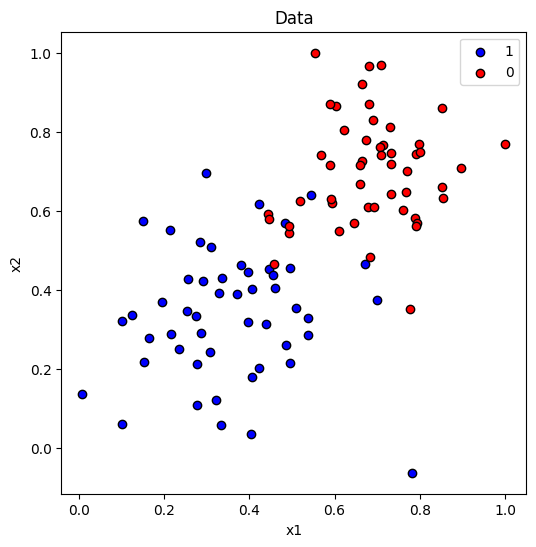

In [4]:
X = df[['x1', 'x2']].values
y = df['y'].values

plt.figure(figsize=(6, 6))
plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', edgecolor='k', label='1')
plt.scatter(X[y==0, 0], X[y==0, 1], c='red', edgecolor='k', label='0')
plt.xlabel('x1'); plt.ylabel('x2'); plt.legend(); plt.title('Data')
plt.show()

Blues (label=1) sit in the lower-left, reds (label=0) in the upper-right. They look roughly linearly separable but with a chunky overlap band along the diagonal — a few reds sneak into the blue cluster and vice versa. So a perceptron should land a decent line but probably won't hit 100%.

## Part 1: Heuristic Perceptron

The heuristic version uses a step function: for each misclassified point, nudge the weights toward the correct side. If a point is labeled 1 but classified as 0, push the line away from it; if labeled 0 but classified as 1, push it back.

In [5]:
def step(z):
    return (z >= 0).astype(int)

def line_from_weights(w, b, x_range):
    return -(w[0] * x_range + b) / w[1]

def heuristic_perceptron(X, y, lr, n_iter, seed=1):
    rng = np.random.default_rng(seed)
    w = rng.uniform(-1, 1, size=2)
    b = rng.uniform(-1, 1)
    history = [(w.copy(), b)]
    for _ in range(n_iter):
        for xi, yi in zip(X, y):
            pred = step(np.dot(w, xi) + b)
            if pred != yi:
                if yi == 1:
                    w += lr * xi
                    b += lr
                else:
                    w -= lr * xi
                    b -= lr
        history.append((w.copy(), b))
    return w, b, history

In [6]:
def plot_history(X, y, history, title):
    x_range = np.array([0, 1])
    plt.figure(figsize=(7, 7))
    plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', edgecolor='k', zorder=3)
    plt.scatter(X[y==0, 0], X[y==0, 1], c='red', edgecolor='k', zorder=3)
    w0, b0 = history[0]
    plt.plot(x_range, line_from_weights(w0, b0, x_range), 'r-', linewidth=2, label='initial')
    for w, b in history[1:-1]:
        plt.plot(x_range, line_from_weights(w, b, x_range), 'g--', alpha=0.4)
    wf, bf = history[-1]
    plt.plot(x_range, line_from_weights(wf, bf, x_range), 'k-', linewidth=2.5, label='final')
    plt.xlim(-0.05, 1.05); plt.ylim(-0.05, 1.05)
    plt.xlabel('x1'); plt.ylabel('x2'); plt.title(title); plt.legend()
    plt.show()

def accuracy(X, y, w, b):
    preds = step(X @ w + b)
    return (preds == y).mean()

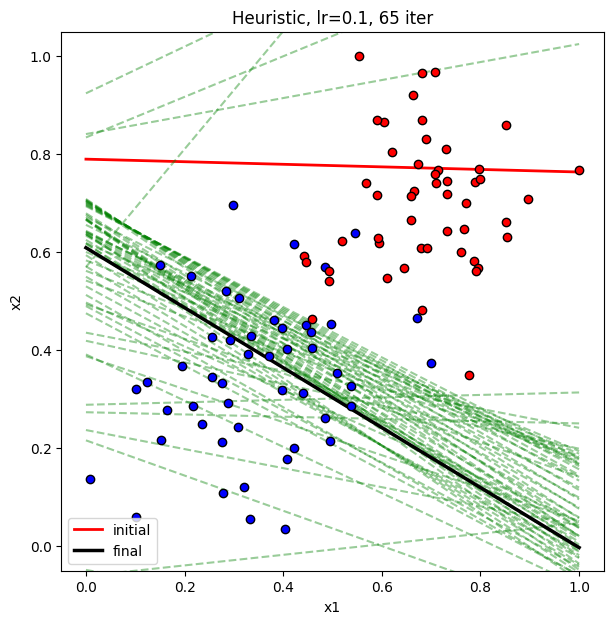

accuracy: 0.78


In [7]:
w, b, hist = heuristic_perceptron(X, y, lr=0.1, n_iter=65)
plot_history(X, y, hist, 'Heuristic, lr=0.1, 65 iter')
print('accuracy:', accuracy(X, y, w, b))

At lr=0.1 the line lands in a diagonal that looks reasonable but accuracy is only 0.78. The fan of greens shows it kept rotating without settling — the heuristic update treats every miss the same regardless of how confident it should have been, so points near the boundary keep yanking the line back and forth.

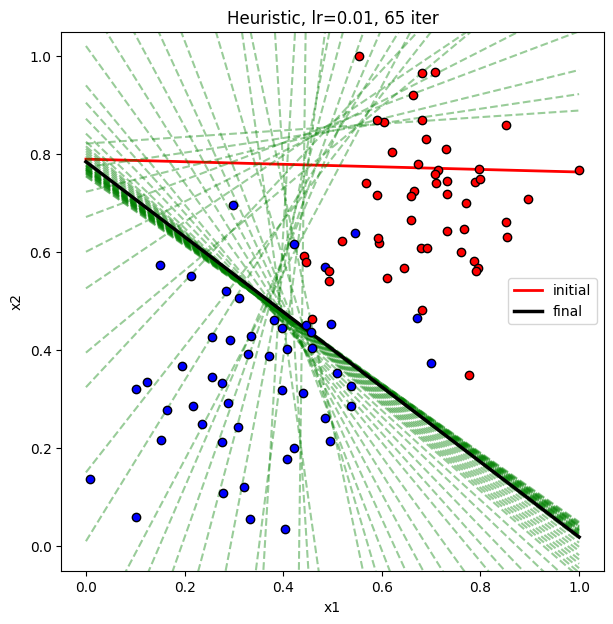

accuracy: 0.91


In [8]:
w, b, hist = heuristic_perceptron(X, y, lr=0.01, n_iter=65)
plot_history(X, y, hist, 'Heuristic, lr=0.01, 65 iter')
print('accuracy:', accuracy(X, y, w, b))

Funnily enough lr=0.01 lands the best of the three at 0.91 accuracy. With tiny steps the greens are bunched in a narrow cone and the final line ends up closer to the initial random one — but apparently that's a better orientation than where lr=0.1 ended up. Sometimes slow and steady wins.

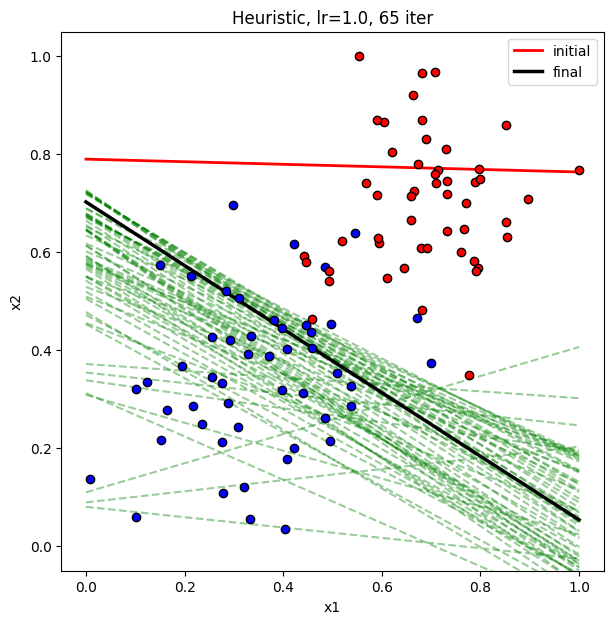

accuracy: 0.88


In [9]:
w, b, hist = heuristic_perceptron(X, y, lr=1.0, n_iter=65)
plot_history(X, y, hist, 'Heuristic, lr=1.0, 65 iter')
print('accuracy:', accuracy(X, y, w, b))

lr=1.0 gives 0.88 accuracy. The greens fan out wildly — every misclassified point throws the line by a full unit in feature space. It's noisy but ends up in a reasonable spot, basically by luck. Lesson: with the heuristic update, larger learning rates don't really 'converge', they just bounce around the rough neighborhood of a solution.

## Part 2: Gradient Descent Perceptron

Now switch to the sigmoid version. The output is continuous (probability), error is `y - ŷ` rather than a 0/1 mismatch, and we track log loss per epoch.

In [10]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def log_loss(y, y_hat):
    eps = 1e-12
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

def gd_perceptron(X, y, lr, n_epochs, seed=1):
    rng = np.random.default_rng(seed)
    w = rng.uniform(-1, 1, size=2)
    b = rng.uniform(-1, 1)
    history = [(w.copy(), b)]
    errors = []
    for epoch in range(n_epochs):
        for xi, yi in zip(X, y):
            y_hat = sigmoid(np.dot(w, xi) + b)
            err = yi - y_hat
            w += lr * err * xi
            b += lr * err
        errors.append(log_loss(y, sigmoid(X @ w + b)))
        if epoch % 10 == 0:
            history.append((w.copy(), b))
    history.append((w.copy(), b))
    return w, b, history, errors

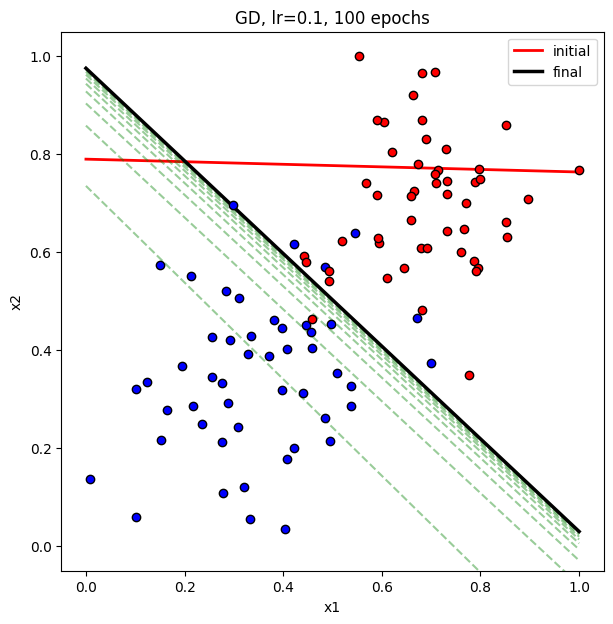

final log loss: 0.16200270066556727 accuracy: 0.93


In [11]:
w, b, hist, errs = gd_perceptron(X, y, lr=0.1, n_epochs=100)
plot_history(X, y, hist, 'GD, lr=0.1, 100 epochs')
print('final log loss:', errs[-1], 'accuracy:', accuracy(X, y, w, b))

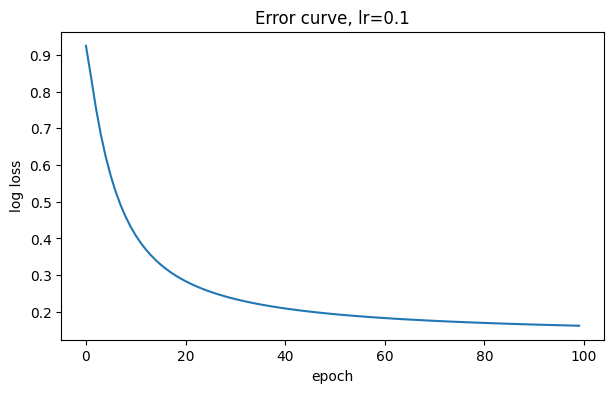

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(errs)
plt.xlabel('epoch'); plt.ylabel('log loss'); plt.title('Error curve, lr=0.1')
plt.show()

Smooth monotonic drop — loss falls fast for the first ~20 epochs then flattens around 0.16. Accuracy 0.93. The boundary plot shows the line sweeping cleanly into place; snapshotting every 10 epochs gives a nice even progression of greens.

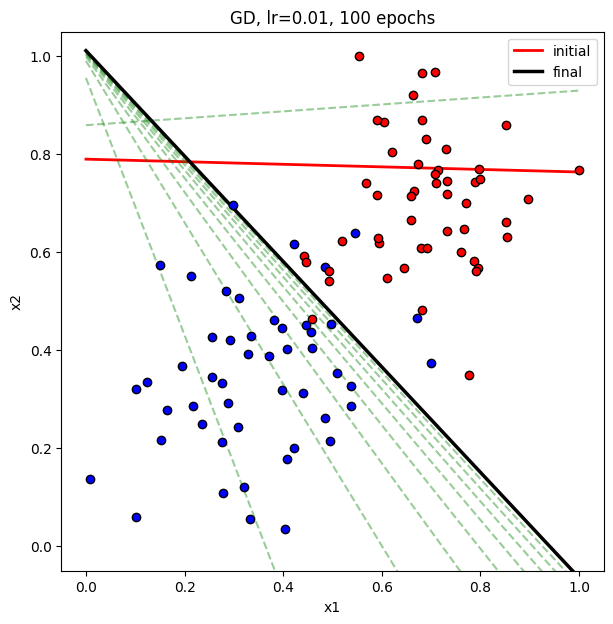

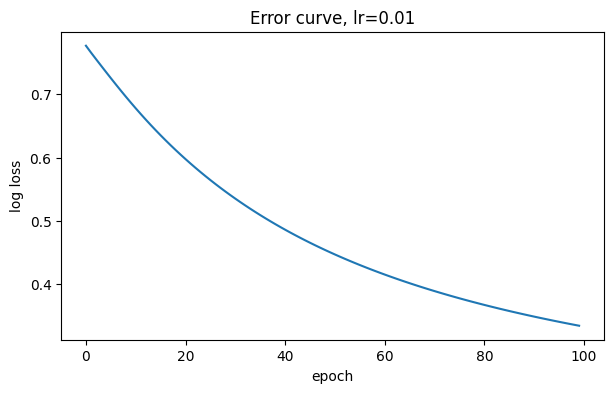

final log loss: 0.33457117691568394 accuracy: 0.93


In [13]:
w, b, hist, errs = gd_perceptron(X, y, lr=0.01, n_epochs=100)
plot_history(X, y, hist, 'GD, lr=0.01, 100 epochs')
plt.figure(figsize=(7, 4))
plt.plot(errs)
plt.xlabel('epoch'); plt.ylabel('log loss'); plt.title('Error curve, lr=0.01')
plt.show()
print('final log loss:', errs[-1], 'accuracy:', accuracy(X, y, w, b))

Smaller lr → much slower descent. Loss is still up at 0.33 after 100 epochs and the line hasn't rotated as far. Accuracy is 0.93 which is the same as lr=0.1, but the loss is double — it would keep improving with more epochs.

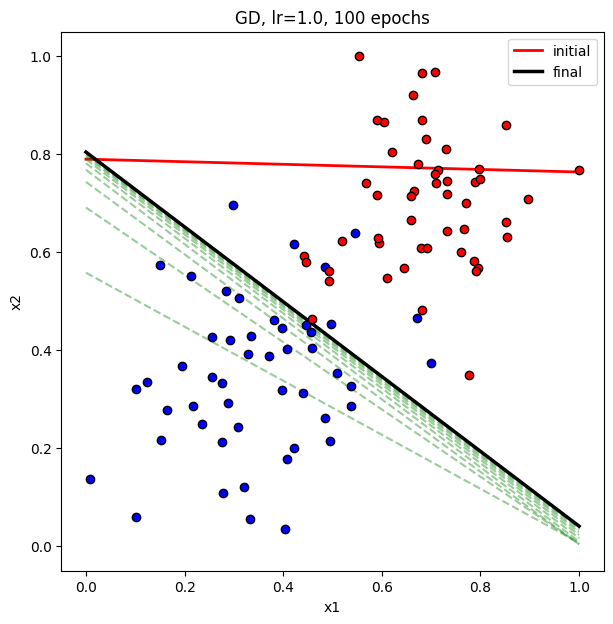

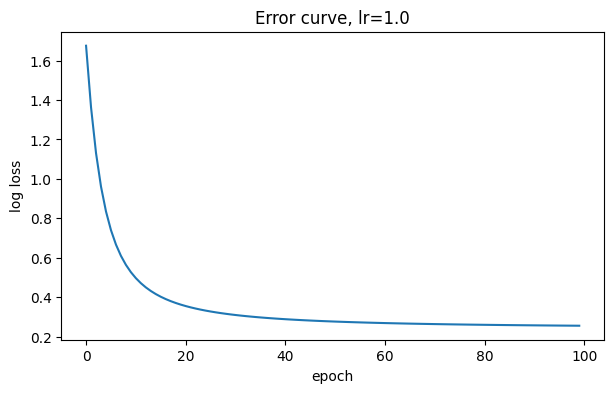

final log loss: 0.2556771410277805 accuracy: 0.93


In [14]:
w, b, hist, errs = gd_perceptron(X, y, lr=1.0, n_epochs=100)
plot_history(X, y, hist, 'GD, lr=1.0, 100 epochs')
plt.figure(figsize=(7, 4))
plt.plot(errs)
plt.xlabel('epoch'); plt.ylabel('log loss'); plt.title('Error curve, lr=1.0')
plt.show()
print('final log loss:', errs[-1], 'accuracy:', accuracy(X, y, w, b))

lr=1.0 lands at loss 0.26 with accuracy 0.93. Faster initial drop than lr=0.1 but the error curve has small bumps where big steps overshoot. Slightly worse final loss than lr=0.1 even with the same number of epochs, because of the oscillation around the minimum.

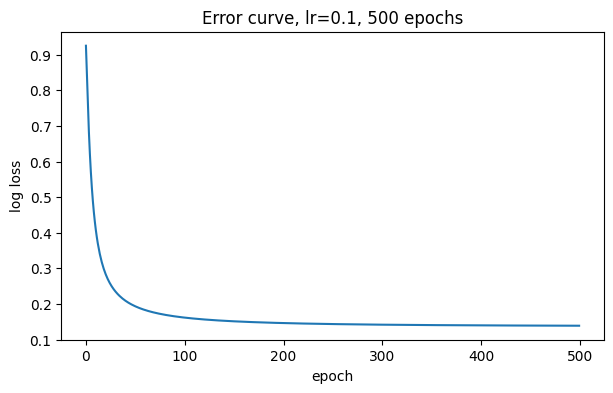

final log loss: 0.13895879768159022 accuracy: 0.94


In [15]:
w, b, hist, errs = gd_perceptron(X, y, lr=0.1, n_epochs=500)
plt.figure(figsize=(7, 4))
plt.plot(errs)
plt.xlabel('epoch'); plt.ylabel('log loss'); plt.title('Error curve, lr=0.1, 500 epochs')
plt.show()
print('final log loss:', errs[-1], 'accuracy:', accuracy(X, y, w, b))

500 epochs at lr=0.1 pushes the loss down to 0.14 and accuracy ticks up to 0.94. That's about as good as it's going to get given the overlap in the middle of the cloud — a few points are genuinely on the wrong side and no straight line can fix that.

## Summary

Both methods land at similar boundaries on this data, but the gradient descent version is way more reliable. The heuristic perceptron is sensitive to learning rate in a non-obvious way (lr=0.01 beat lr=0.1 here) and never gives you a smooth metric to watch. The GD version with sigmoid scales updates by how wrong the prediction was, converges monotonically, and lets you actually plot a loss curve and see what's happening.

For learning rate: lr=0.1 is the sweet spot for GD here. Too small and 100 epochs isn't enough; too big and it oscillates. The error curve makes this immediately visible, which is the real advantage of the gradient descent approach.